# BIRDS SPECIES ANALYSIS 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Import Raw Data

In [3]:
forest = pd.read_excel("C:/Users/khush/OneDrive/Desktop/birds species analysis/data/Bird_Monitoring_Data_FOREST.XLSX",sheet_name = None)

In [4]:
grassland = pd.read_excel("C:/Users/khush/OneDrive/Desktop/birds species analysis/data/Bird_Monitoring_Data_GRASSLAND.XLSX",sheet_name = None)

In [5]:
forest.keys()

dict_keys(['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR'])

In [6]:
grassland.keys()

dict_keys(['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR'])

In [7]:
forest_list = []

for sheet_name, df in forest.items():
    df['Admin_Unit'] = sheet_name
    df['Ecosystem'] = 'Forest'
    forest_list.append(df)

forest_df = pd.concat(forest_list, ignore_index=True)

In [8]:
grass_list = []

for sheet_name, df in grassland.items():
    df['Admin_Unit'] = sheet_name
    df['Ecosystem'] = 'Grassland'
    grass_list.append(df)

grass_df = pd.concat(grass_list, ignore_index=True)

C:\Users\khush\AppData\Local\Temp\ipykernel_11440\3298106699.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grass_df = pd.concat(grass_list, ignore_index=True)


In [9]:
final_df = pd.concat([forest_df, grass_df], ignore_index=True)

In [10]:
print(final_df.shape)
final_df.head()

(17077, 33)


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Admin_Unit,Ecosystem,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,ANTI,Forest,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,ANTI,Forest,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,ANTI,Forest,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,ANTI,Forest,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,ANTI,Forest,NaN,NaN


In [11]:
final_df['Ecosystem'].value_counts()

Ecosystem
Forest       8546
Grassland    8531
Name: count, dtype: int64

In [12]:
final_df['Admin_Unit'].nunique()

11

In [13]:
final_df.isnull().sum().sort_values(ascending=False).head(10)

Sub_Unit_Code      16355
TaxonCode           8548
Previously_Obs      8546
NPSTaxonCode        8531
Site_Name           8531
Sex                 5183
Distance            1486
AcceptedTSN           33
ID_Method              2
Admin_Unit_Code        0
dtype: int64

### Data CLEANING

In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    17077 non-null  object        
 4   Location_Type                17077 non-null  object        
 5   Year                         17077 non-null  object        
 6   Date                         17077 non-null  datetime64[ns]
 7   Start_Time                   17077 non-null  object        
 8   End_Time                     17077 non-null  object        
 9   Observer                     17077 non-null  object        
 10  Visit                        17077 non-null  object        
 11  Interval_Length              17077 non-nu

In [15]:
final_df.isnull().sum().sort_values(ascending=False)

Sub_Unit_Code                  16355
TaxonCode                       8548
Previously_Obs                  8546
NPSTaxonCode                    8531
Site_Name                       8531
Sex                             5183
Distance                        1486
AcceptedTSN                       33
ID_Method                          2
Admin_Unit_Code                    0
Start_Time                         0
Date                               0
Observer                           0
End_Time                           0
Year                               0
Plot_Name                          0
Location_Type                      0
Common_Name                        0
Flyover_Observed                   0
Visit                              0
Interval_Length                    0
PIF_Watchlist_Status               0
Regional_Stewardship_Status        0
Scientific_Name                    0
AOU_Code                           0
Humidity                           0
Temperature                        0
S

In [16]:
final_df.drop(columns=[
    'Sub_Unit_Code',
    'TaxonCode',
    'Previously_Obs',
    'NPSTaxonCode',
    'Site_Name'
], inplace=True)

In [17]:
final_df['Sex'].fillna('Unknown', inplace=True)

C:\Users\khush\AppData\Local\Temp\ipykernel_11440\3239851332.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Sex'].fillna('Unknown', inplace=True)


In [18]:
final_df['Distance'].fillna(final_df['Distance'].mode()[0], inplace=True)

C:\Users\khush\AppData\Local\Temp\ipykernel_11440\2108098517.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Distance'].fillna(final_df['Distance'].mode()[0], inplace=True)


In [19]:
final_df.drop(columns=['AcceptedTSN'], inplace=True)
final_df.drop(columns=['Start_Time'] , inplace = True)
final_df.drop(columns=['End_Time'] , inplace = True)

In [20]:
final_df['ID_Method'].fillna(final_df['ID_Method'].mode()[0], inplace=True)

C:\Users\khush\AppData\Local\Temp\ipykernel_11440\1607784911.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['ID_Method'].fillna(final_df['ID_Method'].mode()[0], inplace=True)


In [21]:
final_df.isnull().sum()

Admin_Unit_Code                0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Initial_Three_Min_Cnt          0
Admin_Unit                     0
Ecosystem                      0
dtype: int64

In [22]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Plot_Name                    17077 non-null  object        
 2   Location_Type                17077 non-null  object        
 3   Year                         17077 non-null  object        
 4   Date                         17077 non-null  datetime64[ns]
 5   Observer                     17077 non-null  object        
 6   Visit                        17077 non-null  object        
 7   Interval_Length              17077 non-null  object        
 8   ID_Method                    17077 non-null  object        
 9   Distance                     17077 non-null  object        
 10  Flyover_Observed             17077 non-null  object        
 11  Sex                          17077 non-nu

In [23]:
final_df['Date'] = pd.to_datetime(final_df['Date'], errors='coerce')

In [24]:
final_df['Date'].dtype

dtype('<M8[ns]')

In [25]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Plot_Name                    17077 non-null  object        
 2   Location_Type                17077 non-null  object        
 3   Year                         17077 non-null  object        
 4   Date                         17077 non-null  datetime64[ns]
 5   Observer                     17077 non-null  object        
 6   Visit                        17077 non-null  object        
 7   Interval_Length              17077 non-null  object        
 8   ID_Method                    17077 non-null  object        
 9   Distance                     17077 non-null  object        
 10  Flyover_Observed             17077 non-null  object        
 11  Sex                          17077 non-nu

### EDA


### Extract month, year and day

In [26]:
final_df['Month']=final_df['Date'].dt.month
final_df['Year']=final_df['Date'].dt.year
final_df['Day']=final_df['Date'].dt.day

In [27]:
final_df.dtypes

Admin_Unit_Code                        object
Plot_Name                              object
Location_Type                          object
Year                                    int32
Date                           datetime64[ns]
Observer                               object
Visit                                  object
Interval_Length                        object
ID_Method                              object
Distance                               object
Flyover_Observed                       object
Sex                                    object
Common_Name                            object
Scientific_Name                        object
AOU_Code                               object
PIF_Watchlist_Status                   object
Regional_Stewardship_Status            object
Temperature                           float64
Humidity                              float64
Sky                                    object
Wind                                   object
Disturbance                       

### SPECIESE ANALYSIS - top bird species 

In [28]:
final_df['Common_Name'].value_counts().head(10)

Common_Name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              739
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64

### Habitat Comparison

In [29]:
final_df['Ecosystem'].value_counts()

Ecosystem
Forest       8546
Grassland    8531
Name: count, dtype: int64

In [49]:

final_df['Plot_Name'].value_counts().head(10)

Plot_Name
MONO-0054    204
MONO-0094    118
MANA-0076    116
MONO-0102     88
MONO-0050     77
MONO-0045     73
ANTI-0188     72
ANTI-0124     71
MONO-0083     68
MANA-0120     63
Name: count, dtype: int64

### TEMPORAL ANALYSIS - Monthly Observation

In [30]:
final_df.groupby('Month').size()

Month
5    5596
6    6596
7    4885
dtype: int64

### ENVIRONMENTAL IMPACT - Weather impact

In [31]:
final_df.groupby('Sky').size()

Sky
Clear or Few Clouds    5809
Cloudy/Overcast        3097
Fog                     647
Mist/Drizzle            379
Partly Cloudy          7145
dtype: int64

### DISTANCE ANALYSIS 

In [32]:
final_df['Distance'].value_counts()

Distance
50 - 100 Meters    9725
<= 50 Meters       7352
Name: count, dtype: int64

### OBSERVER BIAS

In [33]:
final_df['Observer'].value_counts()

Observer
Elizabeth Oswald    6391
Kimberly Serno      5902
Brian Swimelar      4784
Name: count, dtype: int64

### Visit Impact

In [34]:
final_df.groupby('Visit').size()

Visit
1    7588
2    6801
3    2688
dtype: int64

### CONSERVATION ANALYSIS

In [35]:
final_df.groupby('Common_Name')['PIF_Watchlist_Status'].value_counts()

Common_Name              PIF_Watchlist_Status
Acadian Flycatcher       False                   462
American Crow            False                   301
American Goldfinch       False                   509
American Kestrel         False                     8
American Redstart        False                    32
                                                ... 
Yellow-billed Cuckoo     False                   176
Yellow-breasted Chat     False                     9
Yellow-rumped Warbler    False                     3
Yellow-throated Vireo    False                    58
Yellow-throated Warbler  False                     3
Name: count, Length: 126, dtype: int64

In [54]:
# Count number of observations per AOU_Code
aou_counts = final_df.groupby('AOU_Code')['Scientific_Name'].nunique().reset_index()
aou_counts.rename(columns={'Scientific_Name': 'Unique_Species_Count'}, inplace=True)

aou_counts = aou_counts.sort_values(by='Unique_Species_Count', ascending=False)
print(aou_counts.head(10)) 

  AOU_Code  Unique_Species_Count
2     AMGO                     2
0     ACFL                     1
1     AMCR                     1
3     AMKE                     1
4     AMRE                     1
5     AMRO                     1
6     BADO                     1
7     BAEA                     1
8     BAOR                     1
9     BARS                     1


In [55]:
id_method_counts = final_df['ID_Method'].value_counts().reset_index()
id_method_counts.columns = ['ID_Method', 'Count']

print(id_method_counts)

       ID_Method  Count
0        Singing   9865
1        Calling   4061
2  Visualization   3151


In [56]:
# Count number of observations per Interval_Length
interval_counts = final_df['Interval_Length'].value_counts().reset_index()
interval_counts.columns = ['Interval_Length', 'Count']

print(interval_counts)

  Interval_Length  Count
0       0-2.5 min   8614
1     2.5 - 5 min   3410
2     5 - 7.5 min   2720
3    7.5 - 10 min   2333


In [62]:
sex_counts = final_df['Sex'].value_counts().reset_index()
sex_counts.columns = ['Sex', 'Count']
print(sex_counts)

            Sex  Count
0  Undetermined   8410
1       Unknown   5183
2          Male   3338
3        Female    146


In [63]:
# Cross-tab of Sex vs Scientific_Name
species_sex = pd.crosstab(final_df['Scientific_Name'], final_df['Sex'])
print(species_sex)

Sex                     Female  Male  Undetermined  Unknown
Scientific_Name                                            
Accipiter cooperii           0     0             2        0
Agelaius phoeniceus         21   231           164       13
Aix sponsa                   0     2             1        1
Ammodramus savannarum        0   355            32        0
Anas platyrhynchos           0     1             1        2
...                        ...   ...           ...      ...
Vireo gilvus                 0    32            26        0
Vireo griseus                0     0             3       10
Vireo olivaceus              0    45           680       14
Zenaida macroura             0     1           234      162
Zonotrichia albicollis       0     1             0        0

[127 rows x 4 columns]


In [64]:
species_sex['Male_to_Female_Ratio'] = species_sex['Male'] / species_sex['Female'].replace(0, 1)
species_sex_sorted = species_sex.sort_values('Male_to_Female_Ratio', ascending=False)
print(species_sex_sorted.head(10))

Sex                      Female  Male  Undetermined  Unknown  \
Scientific_Name                                                
Spizella pusilla              0   490            52        0   
Ammodramus savannarum         0   355            32        0   
Spizella passerina            0   342            83        1   
Melospiza melodia             0   228            43        0   
Pipilo erythrophthalmus       0   137            98       28   
Geothlypis trichas            1   105            40        0   
Contopus virens               0    88           484        2   
Passerina cyanea              6   474           155        0   
Poecile carolinensis          0    54           183      139   
Vireo olivaceus               0    45           680       14   

Sex                      Male_to_Female_Ratio  
Scientific_Name                                
Spizella pusilla                        490.0  
Ammodramus savannarum                   355.0  
Spizella passerina                     

### DATA VISUALIZATION

#### Top 10 birds species

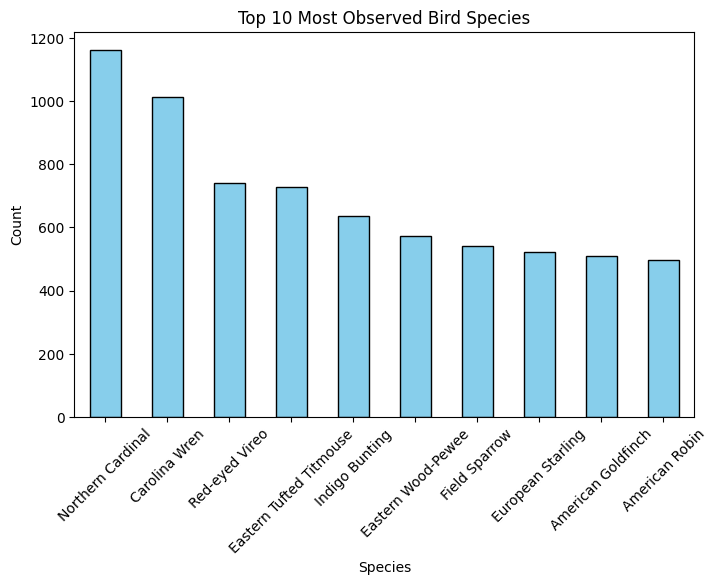

In [36]:
top_species = final_df['Common_Name'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_species.plot(kind='bar' , figsize =(8,5) , color = 'skyblue' , edgecolor = 'black')
plt.title("Top 10 Most Observed Bird Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Habitat Distribution

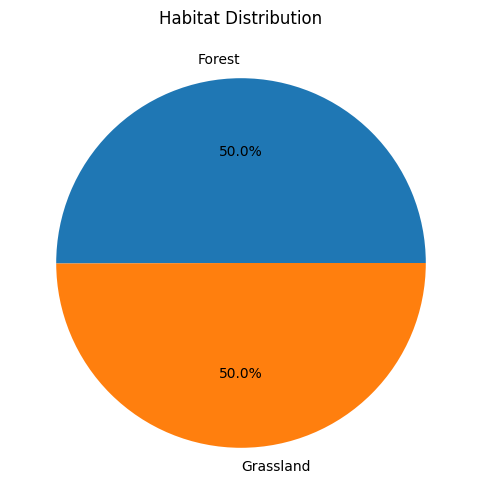

In [37]:
habitat = final_df['Location_Type'].value_counts()

plt.figure(figsize=(6,6))
habitat.plot(kind='pie', autopct='%1.1f%%')
plt.title("Habitat Distribution")
plt.ylabel('')
plt.show()

## Monthly Trend

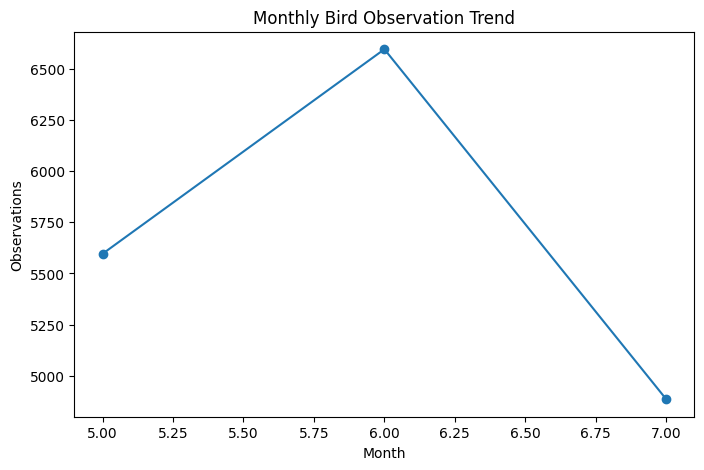

In [38]:
monthly = final_df.groupby('Month').size()

plt.figure(figsize=(8,5))
monthly.plot(kind='line', marker='o')
plt.title("Monthly Bird Observation Trend")
plt.xlabel("Month")
plt.ylabel("Observations")
plt.show()

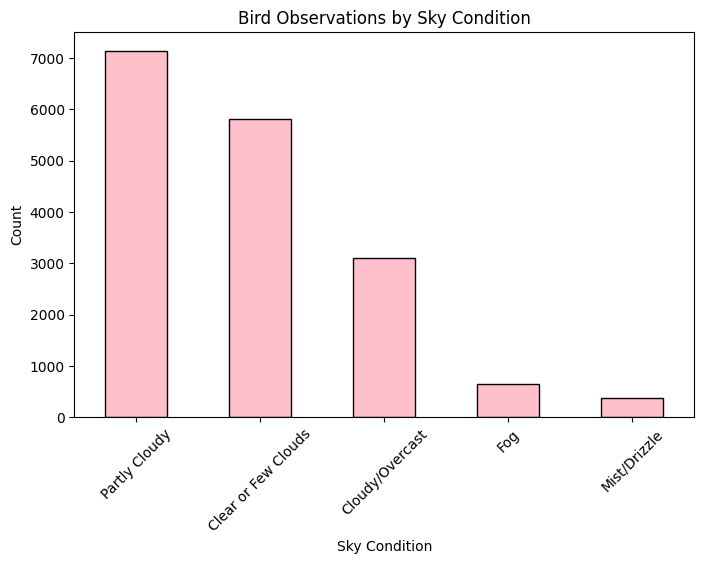

In [39]:
sky = final_df['Sky'].value_counts()

plt.figure(figsize=(8,5))
sky.plot(kind='bar',figsize=(8,5) , color='pink' , edgecolor ='black')
plt.title("Bird Observations by Sky Condition")
plt.xlabel("Sky Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

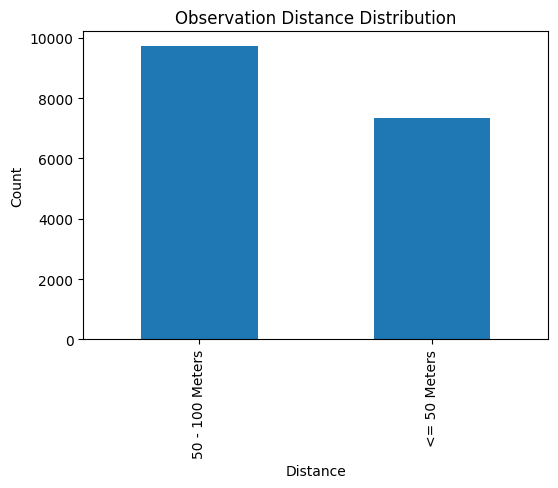

In [40]:
distance = final_df['Distance'].value_counts()

plt.figure(figsize=(6,4))
distance.plot(kind='bar')
plt.title("Observation Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

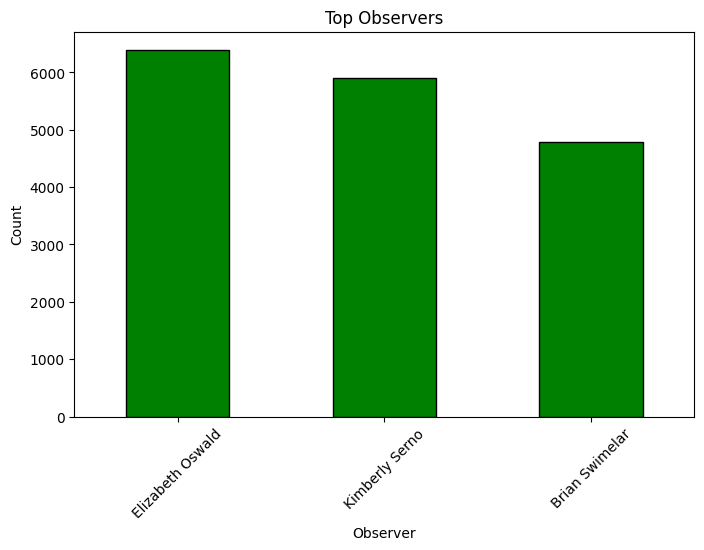

In [41]:
observer = final_df['Observer'].value_counts().head(10)

plt.figure(figsize=(8,5))
observer.plot(kind='bar',figsize =(8,5),color='green',edgecolor='black')
plt.title("Top Observers")
plt.xlabel("Observer")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

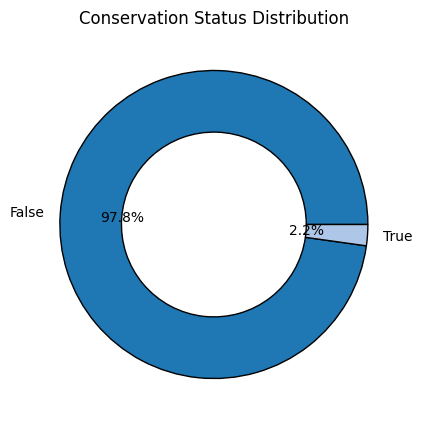

In [42]:
watchlist = final_df['PIF_Watchlist_Status'].value_counts()

plt.figure(figsize=(5,5))
colors=plt.get_cmap('tab20').colors
watchlist.plot(kind='pie', autopct='%1.1f%%',colors = colors, wedgeprops={'edgecolor':'black','width':0.4})
plt.title("Conservation Status Distribution")
plt.ylabel('')
plt.show()


C:\Users\khush\AppData\Local\Temp\ipykernel_11440\2691688396.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_counts.values, y=plot_counts.index, palette='viridis')


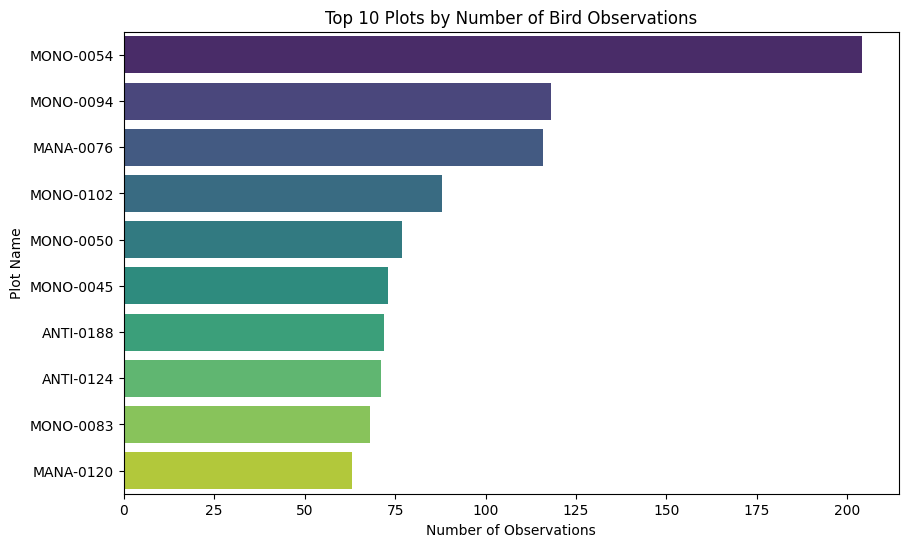

In [51]:
import seaborn as sns

plot_counts = final_df['Plot_Name'].value_counts().head(10)  # Top 10 plots

plt.figure(figsize=(10,6))
sns.barplot(x=plot_counts.values, y=plot_counts.index, palette='viridis')
plt.title('Top 10 Plots by Number of Bird Observations')
plt.xlabel('Number of Observations')
plt.ylabel('Plot Name')
plt.show()

In [52]:
species_per_location = final_df.groupby('Location_Type')['Scientific_Name'].nunique().reset_index()
species_per_location.rename(columns={'Scientific_Name': 'Unique_Species_Count'}, inplace=True)

print(species_per_location)

  Location_Type  Unique_Species_Count
0        Forest                   108
1     Grassland                   107


C:\Users\khush\AppData\Local\Temp\ipykernel_11440\4084310834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location_Type', y='Unique_Species_Count', data=species_per_location, palette='Set2')


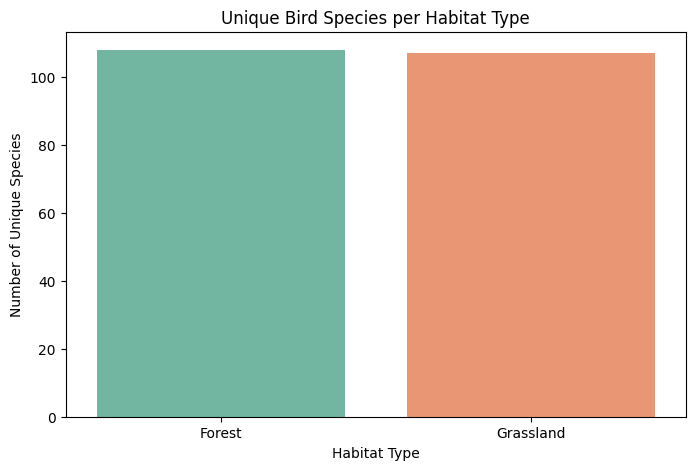

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x='Location_Type', y='Unique_Species_Count', data=species_per_location, palette='Set2')
plt.title('Unique Bird Species per Habitat Type')
plt.xlabel('Habitat Type')
plt.ylabel('Number of Unique Species')
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_11440\115938039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='ID_Method', order=final_df['ID_Method'].value_counts().index, palette='Set2')


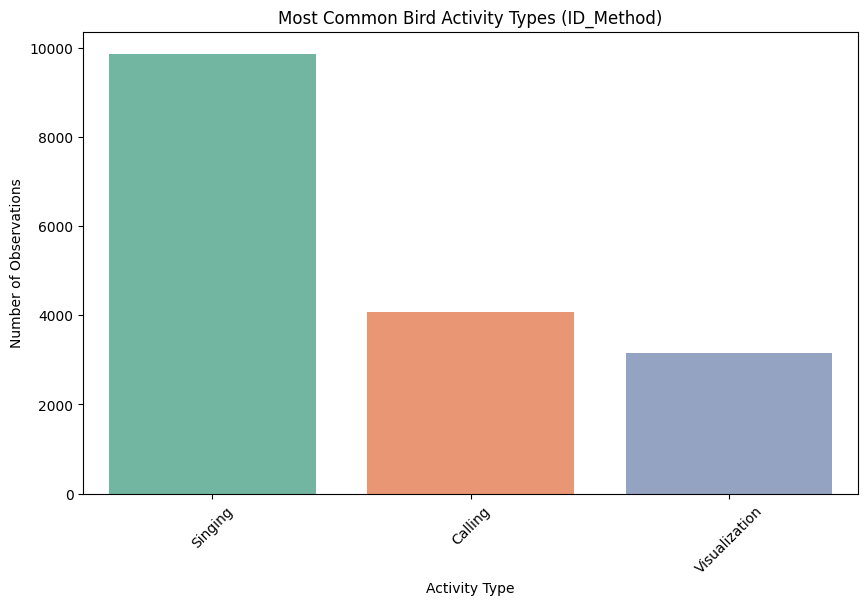

In [57]:

plt.figure(figsize=(10,6))
sns.countplot(data=final_df, x='ID_Method', order=final_df['ID_Method'].value_counts().index, palette='Set2')
plt.title('Most Common Bird Activity Types (ID_Method)')
plt.xlabel('Activity Type')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.show()

In [43]:
final_df.to_csv("cleaned_bird_data.csv", index=False)

In [44]:
print("EDA Completed & Dataset Saved ✅")

EDA Completed & Dataset Saved ✅
